# CDS Visualization

This notebook reads the CDS sheet from the masterfile and plots the sovereign CDS spreads.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Read CDS sheet from masterfile
CDS_df = pd.read_excel('data/raw/data_masterfile.xlsx', sheet_name='CDS')
CDS_df = CDS_df.rename(columns={'Dates': 'Date'})
CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
CDS_df.set_index('Date', inplace=True)
# Read Oil data from csv

Oil_df = pd.read_csv('data/raw/brent_ovx_weekly.csv')
Oil_df['Date'] = pd.to_datetime(Oil_df['Date'])
Oil_df.set_index('Date', inplace=True)

In [18]:
CDS_df.columns = [col.replace('_USD', '') for col in CDS_df.columns]

merged = pd.merge(CDS_df, Oil_df, on='Date', how='inner')
merged.head()

,US,Mexico,Colombia,Brazil,Morocco,Egypt,Poland,Turkey,Kazakhstan,Qatar,SaudiArabia,Iraq,Brent,OVX
Date,,,,,,,,,,,,,,
2008-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.790001,34.500000
2008-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.070000,32.119999
2008-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.230003,31.459999
2008-01-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.900002,31.959999
2008-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.440002,29.770000


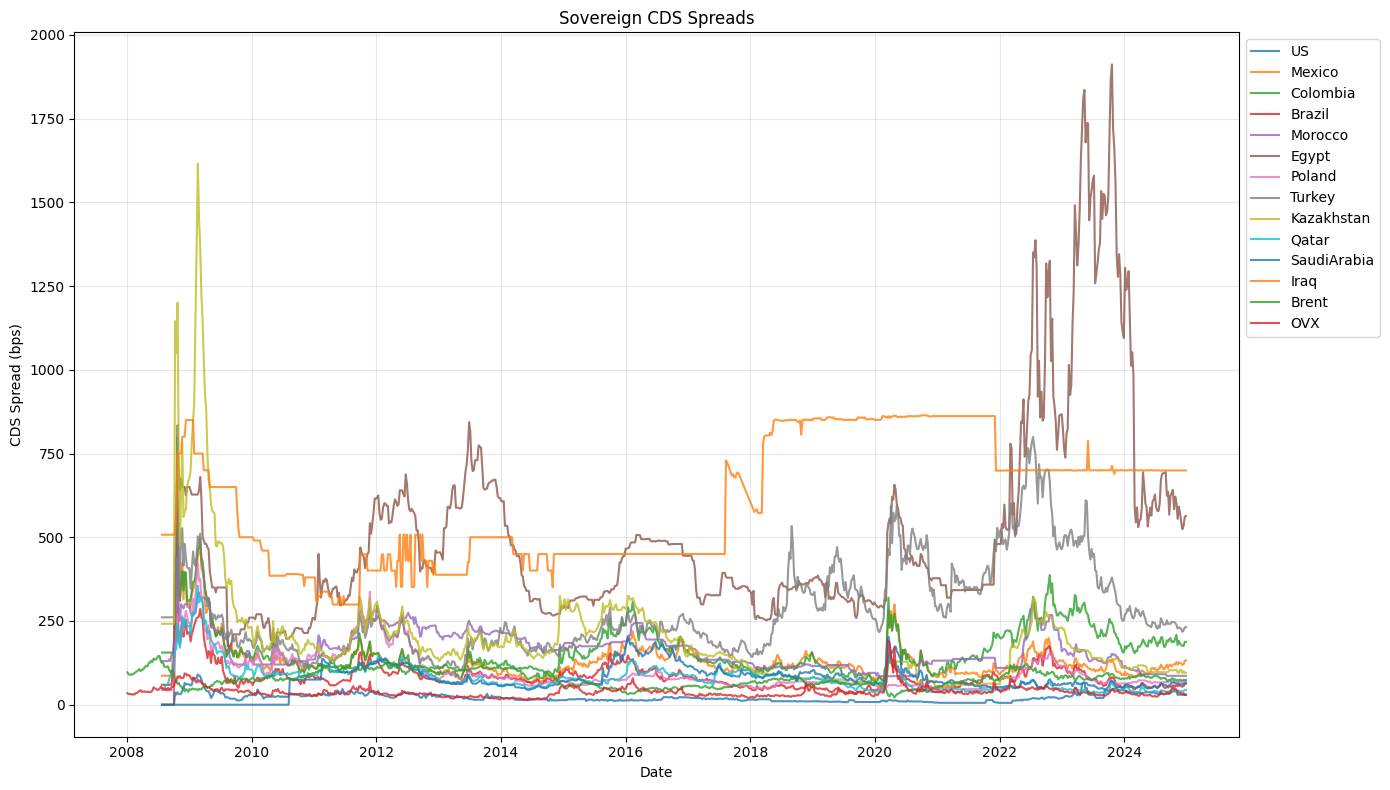

In [19]:
# Plot all CDS spreads
fig, ax = plt.subplots(figsize=(14, 8))

for col in merged.columns:
    ax.plot(merged.index, merged[col], label=col, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('CDS Spread (bps)')
ax.set_title('Sovereign CDS Spreads')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Define your groups
oil_exporters = ['SaudiArabia', 'Qatar', 'Kazakhstan', 'Colombia', 'Mexico']
controls = ['Poland', 'Turkey', 'Morocco', 'Brazil', 'Egypt']

# Compute returns
merged['oil_ret'] = merged['OVX'].pct_change()

# Correlations
print("=== OIL-CDS CORRELATIONS ===\n")
print("Oil Exporters:")
for country in oil_exporters:
    if country in merged.columns:
        cds_ret = merged[country].pct_change()
        corr = merged['oil_ret'].corr(cds_ret)
        print(f"  {country}: {corr:+.3f}")

print("\nControl Group:")
for country in controls:
    if country in merged.columns:
        cds_ret = merged[country].pct_change()
        corr = merged['oil_ret'].corr(cds_ret)
        print(f"  {country}: {corr:+.3f}")

=== OIL-CDS CORRELATIONS ===

Oil Exporters:
  SaudiArabia: +nan
  Qatar: +0.374
  Kazakhstan: +0.207
  Colombia: +0.412
  Mexico: +0.403

Control Group:
  Poland: +0.206
  Turkey: +0.290
  Morocco: +0.120
  Brazil: +0.382
  Egypt: +nan


c:\Users\JuanFranciscoPerez\Projects\commodities_and_sovereigns\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\JuanFranciscoPerez\Projects\commodities_and_sovereigns\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


In [23]:
print(merged['Egypt'].isna().sum())
print(merged['Egypt'].head(20))

29
Date
2008-01-04   NaN
2008-01-11   NaN
2008-01-18   NaN
2008-01-25   NaN
2008-02-01   NaN
2008-02-08   NaN
2008-02-15   NaN
2008-02-22   NaN
2008-02-29   NaN
2008-03-07   NaN
2008-03-14   NaN
2008-03-21   NaN
2008-03-28   NaN
2008-04-04   NaN
2008-04-11   NaN
2008-04-18   NaN
2008-04-25   NaN
2008-05-02   NaN
2008-05-09   NaN
2008-05-16   NaN
Name: Egypt, dtype: float64
